# Mid-Transformer Causal Intervention

This notebook upgrades the project's interpretability methodology from **post-hoc steering on the final pooled embedding** (notebooks 07, 09, 12) to a **true mid-transformer causal trace**, in the spirit of Anthropic's *Emotion Concepts and their Function in a Large Language Model* (Sofroniew et al., 2026).

## Why this matters

In notebook 12 we built emotion directions at every layer but applied them to the *final* pooled embedding. That tells us which layer's geometry is most aligned with the trained classifier head. It does **not** tell us where in the transformer the emotion concept is built up, nor whether intervening at an intermediate layer propagates through the rest of the network in the way the geometry would predict.

This notebook fixes that. For each layer index $\ell$, we register a forward hook on the corresponding wav2vec2 encoder block and:

- **Sufficiency.** Add $\alpha \, \mathbf{d}_\ell^{(c)}$ to every time step at layer $\ell$, then let layers $\ell + 1 \dots 12$ run naturally and measure the classifier probability shift for class $c$.
- **Necessity.** Project out the component along $\mathbf{d}_\ell^{(c)}$ at every time step, propagate, and measure macro-F1 damage.
- **Bidirectional sweep.** Sweep $\alpha \in [-1, 1]$ at selected layers to characterize the response curve.
- **Mid vs post-hoc.** Compare mid-transformer intervention to the post-hoc final-layer steering used in notebook 12.

## Method (one-screen summary)

For an audio waveform $x$, let $\mathbf{H}^{(\ell)} \in \mathbb{R}^{T \times d}$ be the hidden states at the output of transformer layer $\ell$. We intervene with

$$
\widetilde{\mathbf{H}}^{(\ell)}_t \;=\; \mathbf{H}^{(\ell)}_t \;+\; \alpha \, \mathbf{d}_\ell^{(c)} \quad \text{for every } t,
$$

where $\mathbf{d}_\ell^{(c)}$ is the layer-$\ell$ emotion-minus-neutral direction built from training-set centroids. The perturbed $\widetilde{\mathbf{H}}^{(\ell)}$ is what flows into layer $\ell + 1$. After the full forward pass, we mean-pool, classify, and compute $\Delta p_c$.

For necessity:

$$
\widetilde{\mathbf{H}}^{(\ell)}_t \;=\; \mathbf{H}^{(\ell)}_t - (\mathbf{H}^{(\ell)}_t \cdot \hat{\mathbf{d}}_\ell^{(c)}) \, \hat{\mathbf{d}}_\ell^{(c)}.
$$

This is a real intervention on the residual stream, not a rewrite of the final pooled vector. The result is therefore a stronger interpretability claim: if the direction at layer $\ell$ is causally load-bearing, then a perturbation at layer $\ell$ should still affect the output after $12 - \ell$ further nonlinear transformations.

<!-- narrative:14-role -->
## Notebook role in the project

This notebook upgrades steering from a post-hoc embedding edit to an in-model causal intervention. It injects or removes emotion directions inside wav2vec2 while the remaining layers continue the forward pass.

**Inputs:** trained checkpoint, layer-wise embeddings, and test audio.

**Outputs:** sufficiency sweeps, random-vector controls, bidirectional alpha sweeps, necessity results, and summary JSON.

**How to read it:** this is stronger than final-layer steering because the model has to process the edited hidden state through later transformer layers.


In [1]:
from __future__ import annotations

import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/pavannn16/speech-emotion-directions.git"
REPO_NAME = "speech-emotion-directions"
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def running_in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

IS_COLAB = running_in_colab()
print("Running in Colab:", IS_COLAB)

def run_command(cmd, cwd=None):
    print("+", " ".join(cmd))
    subprocess.check_call(cmd, cwd=str(cwd) if cwd else None)

def ensure_packages():
    pkgs = {"yaml": "pyyaml", "pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "torch": "torch", "transformers": "transformers", "sklearn": "scikit-learn", "huggingface_hub": "huggingface_hub", "tqdm": "tqdm"}
    missing = sorted({p for m, p in pkgs.items() if importlib.util.find_spec(m) is None})
    if missing: run_command([sys.executable, "-m", "pip", "install", "-q", *missing])
    else: print("Required packages available.")

def find_local_project_root():
    cwd = Path.cwd().resolve()
    for c in [cwd, cwd.parent, cwd / "FinalProject"]:
        c = c.resolve()
        if (c / "configs" / "wav2vec.yaml").exists() and (c / "src").exists(): return c
    raise FileNotFoundError("Could not find project root.")

def clone_clean(clean_root):
    if clean_root.exists(): shutil.rmtree(clean_root)
    run_command(["git", "clone", "--depth", "1", REPO_URL, str(clean_root)])
    return clean_root

def prepare_roots():
    rt = Path("/content") / REPO_NAME; cl = Path("/content") / f"{REPO_NAME}-clean"
    if rt.exists() and (rt / ".git").exists():
        try: run_command(["git", "-C", str(rt), "fetch", "origin"])
        except: pass
        st = subprocess.run(["git","-C",str(rt),"status","--short"],text=True,capture_output=True,check=True).stdout.splitlines()
        ab = subprocess.run(["git","-C",str(rt),"rev-list","--left-right","--count","HEAD...origin/main"],text=True,capture_output=True,check=False)
        a,b = (0,0) if ab.returncode!=0 or not ab.stdout.strip() else map(int,ab.stdout.strip().split())
        if not [l for l in st if l.strip()] and a==0:
            if b>0:
                try: run_command(["git","-C",str(rt),"pull","--ff-only","origin","main"]); cr=rt
                except: cr=clone_clean(cl)
            else: cr=rt
        else: cr=clone_clean(cl)
        return rt, cr
    elif rt.exists(): return rt, clone_clean(cl)
    else: run_command(["git","clone","--depth","1",REPO_URL,str(rt)]); return rt,rt

ensure_packages()
if IS_COLAB:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT, CODE_ROOT = prepare_roots()
else:
    PROJECT_ROOT = find_local_project_root(); CODE_ROOT = PROJECT_ROOT

os.chdir(PROJECT_ROOT)
for r in [str(CODE_ROOT), str(PROJECT_ROOT)]:
    while r in sys.path: sys.path.remove(r)
sys.path.insert(0, str(CODE_ROOT))
if str(PROJECT_ROOT) != str(CODE_ROOT): sys.path.insert(1, str(PROJECT_ROOT))
for n in [n for n in sys.modules if n == "src" or n.startswith("src.")]: del sys.modules[n]
print("Project root:", PROJECT_ROOT); print("Code root:", CODE_ROOT)

Running in Colab: True
Required packages available.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
+ git -C /content/speech-emotion-directions fetch origin
+ git clone --depth 1 https://github.com/pavannn16/speech-emotion-directions.git /content/speech-emotion-directions-clean
Project root: /content/speech-emotion-directions
Code root: /content/speech-emotion-directions-clean


In [2]:
experiment_name = 'wav2vec_ravdess_speaker_independent_v1'
local_checkpoint_dir = PROJECT_ROOT / 'artifacts' / 'checkpoints' / experiment_name
local_analysis_dir = PROJECT_ROOT / 'artifacts' / 'analysis' / experiment_name
local_output_dir = local_analysis_dir / 'mid_transformer_causal_trace'
local_output_dir.mkdir(parents=True, exist_ok=True)

drive_run_root = Path('/content/drive/MyDrive') / 'speech-emotion-directions' / 'runs' / experiment_name if IS_COLAB else None
drive_checkpoint_dir = drive_run_root / 'checkpoint' if drive_run_root else None
drive_analysis_dir = drive_run_root / 'analysis' if drive_run_root else None
drive_output_dir = drive_analysis_dir / 'mid_transformer_causal_trace' if drive_analysis_dir else None

checkpoint_dir = (
    drive_checkpoint_dir
    if drive_checkpoint_dir is not None and (drive_checkpoint_dir / 'model_state.pt').exists()
    else local_checkpoint_dir
)
analysis_source_dir = (
    drive_analysis_dir
    if drive_analysis_dir is not None and (drive_analysis_dir / 'embedding_arrays.npz').exists()
    else local_analysis_dir
)

print('Checkpoint dir:', checkpoint_dir)
print('Analysis dir :', analysis_source_dir)
print('Output dir   :', local_output_dir)


Checkpoint dir: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/checkpoint
Analysis dir : /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis
Output dir   : /content/speech-emotion-directions/artifacts/analysis/wav2vec_ravdess_speaker_independent_v1/mid_transformer_causal_trace


In [3]:
"""Ensure RAVDESS audio is available from the persistent Drive cache.

Downstream causal notebooks need the actual wav files for fresh forward passes. In
Colab, the Google Drive cache is treated as the durable source. We restore it to
/content for faster dataloading, then rebuild metadata with Colab-local paths.
"""
import shutil as _shutil
import zipfile as _zip

RAVDESS_SOURCES = [
    {
        "name": "RAVDESS Speech 16K",
        "url": "https://zenodo.org/api/records/11063852/files/Audio_Speech_Actors_01-24_16k.zip/content",
        "archive_name": "Audio_Speech_Actors_01-24_16k.zip",
    },
    {
        "name": "RAVDESS Speech Original",
        "url": "https://zenodo.org/api/records/1188976/files/Audio_Speech_Actors_01-24.zip/content",
        "archive_name": "Audio_Speech_Actors_01-24.zip",
    },
]

raw_root = PROJECT_ROOT / "data" / "raw"
extract_dir = raw_root / "ravdess_audio_speech"
metadata_path = PROJECT_ROOT / "data" / "metadata" / "ravdess_metadata.csv"
drive_dataset_dir = (
    Path("/content/drive/MyDrive") / "speech-emotion-directions" / "datasets" / "ravdess_audio_speech"
    if IS_COLAB
    else None
)

raw_root.mkdir(parents=True, exist_ok=True)
metadata_path.parent.mkdir(parents=True, exist_ok=True)


def _count_wavs(root: Path | None) -> int:
    return sum(1 for _ in root.rglob("*.wav")) if root is not None and root.exists() else 0


def _restore_from_drive_cache() -> bool:
    if drive_dataset_dir is None:
        return False
    drive_count = _count_wavs(drive_dataset_dir)
    print("Drive RAVDESS wav cache:", drive_dataset_dir, f"({drive_count} wavs)")
    if drive_count < 1440:
        return False
    if _count_wavs(extract_dir) >= 1440:
        print("Local runtime already has complete RAVDESS audio; Drive cache is available as the persistent source.")
        return True
    if extract_dir.exists():
        _shutil.rmtree(extract_dir)
    extract_dir.parent.mkdir(parents=True, exist_ok=True)
    _shutil.copytree(drive_dataset_dir, extract_dir)
    print("Restored RAVDESS audio from Google Drive cache to:", extract_dir)
    return True


def _cache_to_drive() -> None:
    if drive_dataset_dir is None or _count_wavs(extract_dir) < 1440:
        return
    if _count_wavs(drive_dataset_dir) >= 1440:
        print("Google Drive RAVDESS cache already complete:", drive_dataset_dir)
        return
    if drive_dataset_dir.exists():
        _shutil.rmtree(drive_dataset_dir)
    drive_dataset_dir.parent.mkdir(parents=True, exist_ok=True)
    _shutil.copytree(extract_dir, drive_dataset_dir)
    print("Cached RAVDESS audio in Google Drive:", drive_dataset_dir)


def _download_file(url: str, dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        dest.unlink()
    for tool in ["curl", "wget"]:
        import shutil as sh
        if sh.which(tool) is None:
            continue
        cmd = (
            ["curl", "-L", "--fail", "--retry", "3", "--retry-delay", "5", "-A", "Mozilla/5.0", "-o", str(dest), url]
            if tool == "curl"
            else ["wget", "--tries=3", "--waitretry=5", "--user-agent=Mozilla/5.0", "-O", str(dest), url]
        )
        try:
            import subprocess as sp
            sp.check_call(cmd)
            if dest.exists() and dest.stat().st_size > 0:
                return
        except Exception:
            if dest.exists():
                dest.unlink()
    raise RuntimeError(f"Could not download {url}")


def _ensure_ravdess() -> None:
    print(f"Existing local RAVDESS wav files: {_count_wavs(extract_dir)}")
    if _restore_from_drive_cache():
        return
    if _count_wavs(extract_dir) >= 1440:
        _cache_to_drive()
        return

    downloaded = False
    for src in RAVDESS_SOURCES:
        archive_path = raw_root / src["archive_name"]
        if not (archive_path.exists() and archive_path.stat().st_size > 0):
            try:
                print(f"Downloading {src['name']}...")
                _download_file(src["url"], archive_path)
                downloaded = True
            except RuntimeError as exc:
                print(f"  -> failed: {exc}")
                continue
        else:
            downloaded = True

        if downloaded:
            if extract_dir.exists():
                _shutil.rmtree(extract_dir)
            extract_dir.mkdir(parents=True, exist_ok=True)
            print("Extracting archive...")
            with _zip.ZipFile(archive_path, "r") as zf:
                zf.extractall(extract_dir)
            if _count_wavs(extract_dir) >= 1440:
                break

    if _count_wavs(extract_dir) < 1440:
        print("Falling back to HuggingFace RAVDESS mirror...")
        from huggingface_hub import snapshot_download
        snapshot_download(
            repo_id="birgermoell/ravdess",
            repo_type="dataset",
            local_dir=extract_dir,
            allow_patterns=["Actor_*/*.wav"],
        )

    wav_count = _count_wavs(extract_dir)
    print(f"RAVDESS wav files after setup: {wav_count}")
    assert wav_count >= 1440, f"Expected >=1440 wavs, found {wav_count}"
    _cache_to_drive()


if IS_COLAB:
    _ensure_ravdess()
    from src.data.ravdess_metadata import build_ravdess_metadata, save_metadata
    _df = build_ravdess_metadata(extract_dir)
    save_metadata(_df, metadata_path)
    print("Metadata rebuilt at:", metadata_path)
else:
    if not extract_dir.exists() or _count_wavs(extract_dir) < 1440:
        print(f"WARNING: Audio not found at {extract_dir}.")

RAW_AUDIO_ROOT = extract_dir
print("RAW_AUDIO_ROOT:", RAW_AUDIO_ROOT, f"({_count_wavs(RAW_AUDIO_ROOT)} wavs)")


Existing local RAVDESS wav files: 1440
Drive RAVDESS wav cache: /content/drive/MyDrive/speech-emotion-directions/datasets/ravdess_audio_speech (1440 wavs)
Local runtime already has complete RAVDESS audio; Drive cache is available as the persistent source.
Metadata rebuilt at: /content/speech-emotion-directions/data/metadata/ravdess_metadata.csv
RAW_AUDIO_ROOT: /content/speech-emotion-directions/data/raw/ravdess_audio_speech (1440 wavs)


In [4]:
import json
import math

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from src.analysis.advanced_analysis import build_layerwise_directions
from src.analysis.emotion_vectors import (
    build_direction_vectors,
    compute_class_centroids,
    linear_classifier_probabilities,
    load_embedding_artifacts,
)
from src.analysis.extract_embeddings import load_trained_checkpoint
from src.data.dataset import (
    EmotionLabelEncoder,
    RavdessWav2VecDataset,
    Wav2VecCollator,
    load_project_metadata,
)
from src.training.train_wav2vec import (
    get_best_available_device,
    move_batch_to_device,
    resolve_project_path,
)

# ---------------- cached embedding artifacts ----------------
artifacts = load_embedding_artifacts(analysis_source_dir)
label_names = list(artifacts.summary['label_names'])
reference_label = 'neutral'
reference_idx = label_names.index(reference_label)
num_labels = len(label_names)
label_ids = artifacts.true_label_ids
split_array = artifacts.metadata['split'].to_numpy()
train_mask = split_array == 'train'
test_mask = split_array == 'test'
test_label_ids = label_ids[test_mask]
target_ids = [i for i in range(num_labels) if i != reference_idx]

num_layer_slots = int(artifacts.layer_embeddings.shape[1])  # 13 = input + 12 transformer outputs
num_transformer_layers = num_layer_slots - 1  # 12
print(f'Layer slots in artifacts: {num_layer_slots} (slot 0 = pre-encoder, slots 1..{num_transformer_layers} = layer outputs)')
print(f'Test samples: {int(test_mask.sum())}, Labels: {label_names}')

# ---------------- model checkpoint ----------------
device = get_best_available_device()
print(f'Compute device: {device}')

checkpoint = load_trained_checkpoint(checkpoint_dir, device=device)
model = checkpoint.model
model.eval()
classifier_weight = model.classifier.weight.detach().cpu().numpy()
classifier_bias = model.classifier.bias.detach().cpu().numpy()
hidden_size = int(model.backbone.config.hidden_size)
encoder_layers = model.backbone.encoder.layers
print(f'Hidden size: {hidden_size}; encoder.layers: {len(encoder_layers)}')

Layer slots in artifacts: 13 (slot 0 = pre-encoder, slots 1..12 = layer outputs)
Test samples: 208, Labels: ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']
Compute device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hidden size: 768; encoder.layers: 12


## 1. Per-layer emotion directions

We use the training-set centroids cached in `artifacts.layer_embeddings` (shape `(N, 13, 768)`) to build emotion-minus-neutral direction vectors at every layer slot. These are the same directions used elsewhere in the project, but indexed by layer.

<!-- narrative:14-layer-directions -->
## Per-layer directions for live intervention

These directions are built for each layer slot, not just the final embedding. They become the vectors injected into the model through forward hooks.


In [5]:
layerwise_directions_np = build_layerwise_directions(
    layer_embeddings=artifacts.layer_embeddings,
    label_ids=label_ids,
    split_mask=train_mask,
    label_names=label_names,
    reference_idx=reference_idx,
)
print(f'Per-layer direction tensor shape: {layerwise_directions_np.shape}')

direction_norms = np.linalg.norm(layerwise_directions_np, axis=-1)  # (num_layer_slots, num_labels)
norm_df = pd.DataFrame(direction_norms, columns=label_names)
norm_df.index.name = 'layer_index'
display(norm_df.round(3).head(num_layer_slots))

layerwise_directions_t = torch.from_numpy(layerwise_directions_np).to(device).float()
print(f'On device: {layerwise_directions_t.device}, dtype: {layerwise_directions_t.dtype}')

Per-layer direction tensor shape: (13, 6, 768)


,neutral,happy,sad,angry,fearful,disgust
layer_index,,,,,,
0,0.0,0.856,0.459,1.028,1.005,0.518
1,0.0,0.825,0.411,0.990,0.929,0.533
2,0.0,0.968,0.491,1.229,1.129,0.671
3,0.0,1.241,0.657,1.607,1.442,0.968
4,0.0,1.692,0.963,2.233,1.865,1.444
5,0.0,2.145,1.489,2.884,2.505,2.321
6,0.0,2.689,2.120,3.583,3.593,3.449
7,0.0,3.294,3.189,4.617,5.236,4.443
8,0.0,4.024,4.473,5.468,6.713,5.592


On device: cuda:0, dtype: torch.float32


## 2. Forward-hook causal-intervention infrastructure

`LayerIntervention` is a context manager that registers a PyTorch forward hook on a chosen wav2vec2 encoder block. Inside the `with` block, every forward pass through the model has its hidden states at that layer perturbed in place; the rest of the network propagates the perturbation naturally.

Layer-index convention (matches the artifact cache):

- `layer_index = 0` &mdash; *pre-encoder*: a `forward_pre_hook` on `encoder.layers[0]` perturbs the encoder input (this is `hidden_states[0]` in HuggingFace terms).
- `layer_index = k` for `k ∈ [1, 12]` &mdash; *post-layer-k output*: a forward hook on `encoder.layers[k - 1]` perturbs its output (this is `hidden_states[k]`).

Two intervention modes:

- `mode='add'`: $\widetilde{\mathbf{H}}_t = \mathbf{H}_t + \alpha\,\mathbf{d}$ &mdash; sufficiency / steering.
- `mode='ablate'`: $\widetilde{\mathbf{H}}_t = \mathbf{H}_t - (\mathbf{H}_t \cdot \hat{\mathbf{d}})\,\hat{\mathbf{d}}$ &mdash; necessity / projection ablation.

Both modes broadcast over the time axis (the same direction is added to every token); the wav2vec2 attention mask handles padded positions downstream, and the classifier head consumes the masked mean-pool, so padding is benign.

<!-- narrative:14-hook-infra -->
## Forward-hook intervention infrastructure

The hook is the mechanism that makes this notebook causal. It edits hidden states during the actual wav2vec2 forward pass, then lets the downstream layers respond naturally.


In [6]:
class LayerIntervention:
    """Context manager for in-place causal interventions on a wav2vec2 encoder layer.

    Parameters
    ----------
    model : Wav2VecEmotionClassifier
    layer_index : int
        0 -> forward_pre_hook on encoder.layers[0] (perturbs encoder input).
        k (1..12) -> forward_hook on encoder.layers[k - 1] (perturbs layer-k output).
    direction_vec : torch.Tensor of shape (hidden_size,) on the model device
    alpha : float
    mode : {"add", "ablate"}
    """

    def __init__(self, model, layer_index, direction_vec, alpha=0.0, mode='add'):
        n_layers = len(model.backbone.encoder.layers)
        if layer_index < 0 or layer_index > n_layers:
            raise ValueError(f'layer_index {layer_index} out of [0, {n_layers}]')
        if mode not in ('add', 'ablate'):
            raise ValueError(f'unknown mode: {mode}')
        if direction_vec.dim() != 1:
            raise ValueError(f'direction_vec must be 1-D; got shape {tuple(direction_vec.shape)}')

        self.model = model
        self.layer_index = int(layer_index)
        self.direction = direction_vec.detach()
        self.alpha = float(alpha)
        self.mode = mode
        self.handle = None

    def _build_hooks(self):
        d = self.direction
        if self.mode == 'add':
            scaled = (self.alpha * d).to(d.dtype)

            def post_hook(module, inputs, output):
                if isinstance(output, tuple):
                    hidden = output[0]
                    return (hidden + scaled[None, None, :],) + tuple(output[1:])
                return output + scaled[None, None, :]

            def pre_hook(module, inputs):
                hidden = inputs[0]
                return (hidden + scaled[None, None, :],) + tuple(inputs[1:])

            return post_hook, pre_hook

        # mode == 'ablate'
        d_hat = d / (d.norm() + 1e-12)

        def post_hook(module, inputs, output):
            if isinstance(output, tuple):
                hidden = output[0]
                proj = torch.matmul(hidden, d_hat).unsqueeze(-1) * d_hat[None, None, :]
                return (hidden - proj,) + tuple(output[1:])
            proj = torch.matmul(output, d_hat).unsqueeze(-1) * d_hat[None, None, :]
            return output - proj

        def pre_hook(module, inputs):
            hidden = inputs[0]
            proj = torch.matmul(hidden, d_hat).unsqueeze(-1) * d_hat[None, None, :]
            return (hidden - proj,) + tuple(inputs[1:])

        return post_hook, pre_hook

    def __enter__(self):
        post_hook, pre_hook = self._build_hooks()
        if self.layer_index == 0:
            self.handle = self.model.backbone.encoder.layers[0].register_forward_pre_hook(pre_hook)
        else:
            self.handle = self.model.backbone.encoder.layers[self.layer_index - 1].register_forward_hook(post_hook)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        if self.handle is not None:
            self.handle.remove()
            self.handle = None


class _NullCtx:
    def __enter__(self): return self
    def __exit__(self, *a): pass


def softmax_np(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.clip(exp.sum(axis=1, keepdims=True), 1e-12, None)


def build_test_dataloader(checkpoint, batch_size=8, raw_audio_root=None):
    """Build a test DataLoader from the checkpoint config.

    raw_audio_root : Path | None
        If set, `load_project_metadata` remaps file_path columns to this directory
        so that metadata CSVs with stale absolute paths (e.g. from another machine)
        still resolve correctly.  Pass the Colab-local extract_dir here.
    """
    metadata_path = resolve_project_path(checkpoint.config['metadata_path'])
    metadata = load_project_metadata(metadata_path, split='test', raw_audio_root=raw_audio_root)
    dataset = RavdessWav2VecDataset(
        metadata=metadata,
        label_encoder=checkpoint.label_encoder,
        sample_rate=int(checkpoint.config['sample_rate']),
    )
    collator = Wav2VecCollator(
        feature_extractor=checkpoint.feature_extractor,
        sample_rate=int(checkpoint.config['sample_rate']),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collator)


def run_with_optional_intervention(model, dataloader, device, intervention=None):
    """Run a full pass over the dataloader, optionally inside a LayerIntervention.

    Returns concatenated logits and labels in dataloader order.
    """
    ctx = intervention if intervention is not None else _NullCtx()
    all_logits, all_labels = [], []
    with torch.inference_mode():
        with ctx:
            for batch in dataloader:
                model_inputs = move_batch_to_device(batch, device)
                outputs = model(
                    input_values=model_inputs['input_values'],
                    attention_mask=model_inputs.get('attention_mask'),
                )
                all_logits.append(outputs.logits.detach().cpu().numpy())
                all_labels.append(model_inputs['labels'].detach().cpu().numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)


# Build dataloader and a baseline (no intervention) reference run
test_loader = build_test_dataloader(checkpoint, batch_size=8, raw_audio_root=RAW_AUDIO_ROOT)
print(f'Test loader: {len(test_loader)} batches, batch size 8')

base_logits, base_labels = run_with_optional_intervention(model, test_loader, device, intervention=None)
base_probs = softmax_np(base_logits)
base_preds = base_probs.argmax(axis=1)
base_acc = float(accuracy_score(base_labels, base_preds))
base_macro_f1 = float(f1_score(base_labels, base_preds, average='macro', zero_division=0))
print(f'Baseline (no intervention): accuracy={base_acc:.4f}, macro F1={base_macro_f1:.4f}')

# Sanity: dataloader order must match cached test labels
np.testing.assert_array_equal(base_labels, test_label_ids)
print('Sanity: dataloader order matches cached test labels.')

Test loader: 26 batches, batch size 8
Baseline (no intervention): accuracy=0.8221, macro F1=0.8050
Sanity: dataloader order matches cached test labels.


## 3. Experiment 1 &mdash; Mid-transformer sufficiency sweep

For every layer index $\ell \in [0, 12]$ and every non-neutral target emotion $c$, perturb hidden states at layer $\ell$ by $+\,0.5\,\mathbf{d}_\ell^{(c)}$ and let the rest of the network propagate. Record the mean change in classifier probability for class $c$.

This is the analog of Anthropic's *patching* experiments: if class $c$ is genuinely encoded along $\mathbf{d}_\ell^{(c)}$ at layer $\ell$, an additive intervention there must surface as increased probability of $c$ at the output.

<!-- narrative:14-sufficiency -->
## Sufficiency sweep

This experiment asks: if we add an emotion direction inside the model, is that sufficient to increase the target emotion probability? The best layer tells us where the representation is most causally actionable.


In [7]:
SUFF_ALPHA = 0.5
suff_rows = []
total_jobs = num_layer_slots * len(target_ids)
pbar = tqdm(total=total_jobs, desc='sufficiency')
for layer_idx in range(num_layer_slots):
    for target_id in target_ids:
        direction_vec = layerwise_directions_t[layer_idx, target_id]
        if float(direction_vec.norm().item()) < 1e-8:
            pbar.update(1)
            continue
        intervention = LayerIntervention(
            model=model,
            layer_index=layer_idx,
            direction_vec=direction_vec,
            alpha=SUFF_ALPHA,
            mode='add',
        )
        logits, _ = run_with_optional_intervention(model, test_loader, device, intervention)
        probs = softmax_np(logits)
        target_mask = test_label_ids == target_id
        suff_rows.append({
            'layer_index': int(layer_idx),
            'target_label': label_names[target_id],
            'alpha': SUFF_ALPHA,
            'mean_target_prob_steered': float(probs[:, target_id].mean()),
            'delta_target_prob_all': float((probs[:, target_id] - base_probs[:, target_id]).mean()),
            'delta_target_prob_true_subset': float((probs[target_mask, target_id] - base_probs[target_mask, target_id]).mean()) if target_mask.any() else float('nan'),
            'pred_as_target_rate': float((probs.argmax(axis=1) == target_id).mean()),
        })
        pbar.update(1)
pbar.close()

suff_df = pd.DataFrame(suff_rows)
suff_df.to_csv(local_output_dir / 'sufficiency_layer_target_sweep.csv', index=False)
print(f'\nSufficiency sweep: {len(suff_df)} rows')
display(suff_df.round(4).head(10))

sufficiency:   0%|          | 0/65 [00:00<?, ?it/s]


Sufficiency sweep: 65 rows


,layer_index,target_label,alpha,mean_target_prob_steered,delta_target_prob_all,delta_target_prob_true_subset,pred_as_target_rate
0,0,happy,0.5,0.1654,0.0098,0.0277,0.1635
1,0,sad,0.5,0.1570,0.0056,0.0100,0.1587
2,0,angry,0.5,0.1900,0.0000,-0.0037,0.1875
3,0,fearful,0.5,0.0934,0.0018,0.0096,0.0865
4,0,disgust,0.5,0.1531,-0.0005,-0.0022,0.1587
5,1,happy,0.5,0.1635,0.0078,0.0168,0.1635
6,1,sad,0.5,0.1634,0.0120,0.0224,0.1731
7,1,angry,0.5,0.1937,0.0037,0.0102,0.1923
8,1,fearful,0.5,0.0970,0.0054,0.0119,0.0962
9,1,disgust,0.5,0.1563,0.0028,0.0044,0.1635


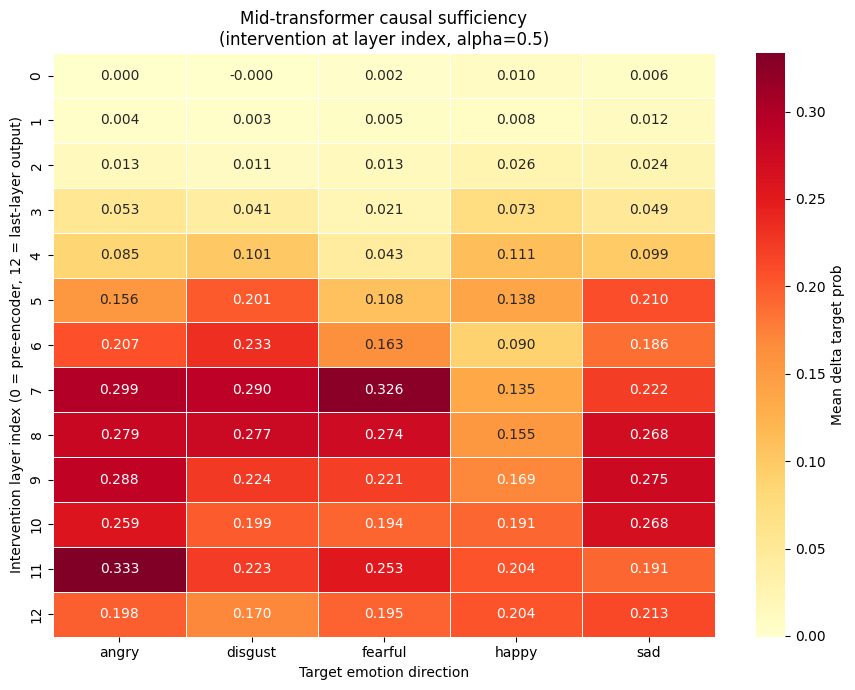

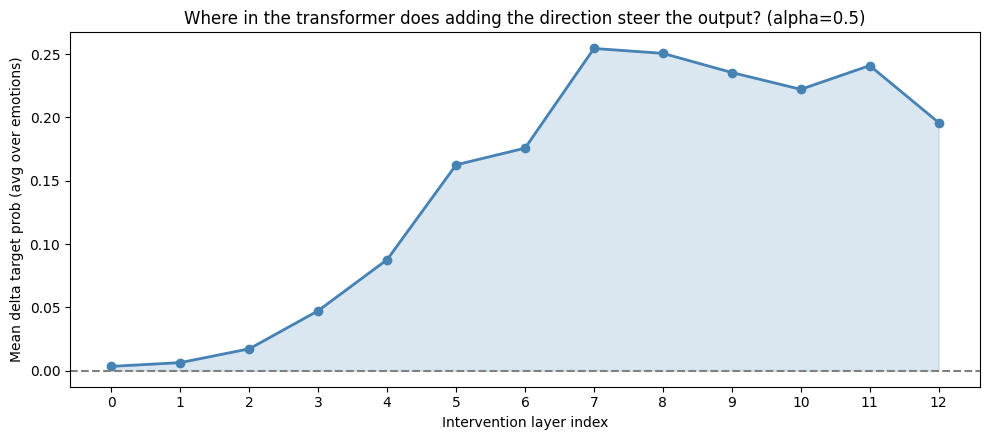

Most effective sufficiency layer: 7
Least effective sufficiency layer: 0


In [8]:
pivot_suff = suff_df.pivot(index='layer_index', columns='target_label', values='delta_target_prob_all')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot_suff, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.4, cbar_kws={'label': 'Mean delta target prob'})
ax.set_title(f'Mid-transformer causal sufficiency\n(intervention at layer index, alpha={SUFF_ALPHA})')
ax.set_ylabel('Intervention layer index (0 = pre-encoder, 12 = last-layer output)')
ax.set_xlabel('Target emotion direction')
plt.tight_layout()
plt.savefig(local_output_dir / 'sufficiency_heatmap.png', dpi=220)
plt.show()

avg_by_layer = suff_df.groupby('layer_index')['delta_target_prob_all'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(avg_by_layer['layer_index'], avg_by_layer['delta_target_prob_all'], marker='o', linewidth=2, color='steelblue')
ax.fill_between(avg_by_layer['layer_index'], 0, avg_by_layer['delta_target_prob_all'], alpha=0.2, color='steelblue')
ax.set_xticks(range(num_layer_slots))
ax.set_xlabel('Intervention layer index')
ax.set_ylabel('Mean delta target prob (avg over emotions)')
ax.set_title(f'Where in the transformer does adding the direction steer the output? (alpha={SUFF_ALPHA})')
ax.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig(local_output_dir / 'sufficiency_layer_curve.png', dpi=220)
plt.show()

best_layer_suff = int(avg_by_layer.loc[avg_by_layer['delta_target_prob_all'].idxmax(), 'layer_index'])
worst_layer_suff = int(avg_by_layer.loc[avg_by_layer['delta_target_prob_all'].idxmin(), 'layer_index'])
print(f'Most effective sufficiency layer: {best_layer_suff}')
print(f'Least effective sufficiency layer: {worst_layer_suff}')

## 3b. Norm-Matched Random-Vector Sufficiency Control

A strong steering effect is only meaningful if the learned emotion direction beats arbitrary perturbations of the same size. This control injects norm-matched random vectors at the best sufficiency layer and compares their target-probability shifts to the real emotion directions.


<!-- narrative:14-random-control -->
## Norm-matched random-vector control

A hidden-state injection is only convincing if real emotion directions outperform random vectors with the same norm. This control rules out the explanation that any perturbation would steer the model.


random-vector control targets:   0%|          | 0/5 [00:00<?, ?it/s]

,target_label,real_delta_target_prob_all,random_mean_delta,random_q05_delta,random_q95_delta,fraction_random_ge_real
0,angry,0.2991,0.0023,-0.0096,0.0126,0.0
1,disgust,0.2901,-0.0057,-0.0226,0.0154,0.0
2,fearful,0.3262,-0.0004,-0.0125,0.0171,0.0
3,happy,0.1354,0.0066,-0.0057,0.0214,0.0
4,sad,0.2217,0.0086,-0.0061,0.0205,0.0


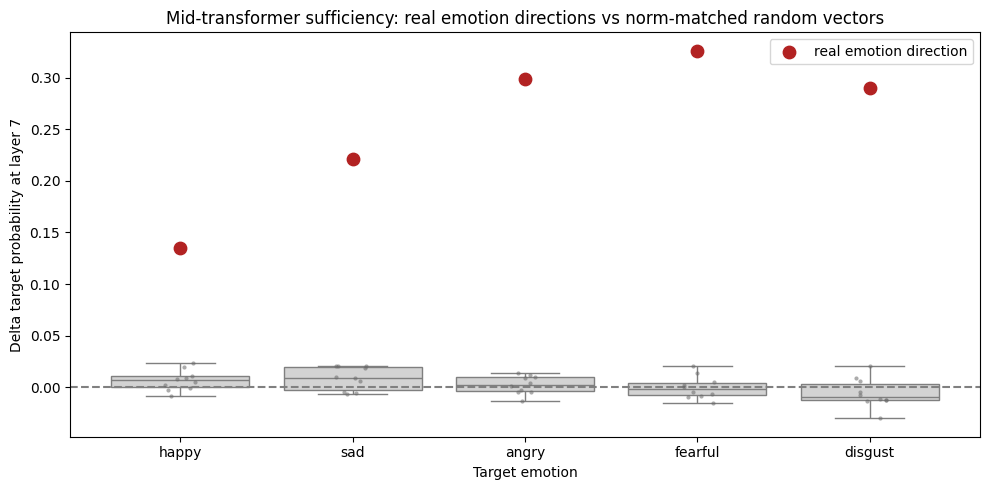

In [9]:
RANDOM_CONTROL_DRAWS = 10
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

random_control_rows = []
real_at_best = suff_df[suff_df['layer_index'] == best_layer_suff].set_index('target_label')

for target_id in tqdm(target_ids, desc='random-vector control targets'):
    target_label = label_names[target_id]
    real_direction = layerwise_directions_np[best_layer_suff, target_id]
    real_norm = float(np.linalg.norm(real_direction))
    if real_norm < 1e-8:
        continue
    target_mask = test_label_ids == target_id
    for draw in range(RANDOM_CONTROL_DRAWS):
        random_np = rng.normal(size=real_direction.shape).astype(np.float32)
        random_np = random_np / np.clip(np.linalg.norm(random_np), 1e-12, None) * real_norm
        random_vec = torch.from_numpy(random_np).to(device).float()
        intervention = LayerIntervention(
            model=model,
            layer_index=best_layer_suff,
            direction_vec=random_vec,
            alpha=SUFF_ALPHA,
            mode='add',
        )
        logits, _ = run_with_optional_intervention(model, test_loader, device, intervention)
        probs = softmax_np(logits)
        random_control_rows.append({
            'draw': int(draw),
            'layer_index': int(best_layer_suff),
            'target_label': target_label,
            'alpha': float(SUFF_ALPHA),
            'control_type': 'norm_matched_random_vector',
            'random_delta_target_prob_all': float((probs[:, target_id] - base_probs[:, target_id]).mean()),
            'random_delta_target_prob_true_subset': float((probs[target_mask, target_id] - base_probs[target_mask, target_id]).mean()) if target_mask.any() else float('nan'),
            'real_delta_target_prob_all': float(real_at_best.loc[target_label, 'delta_target_prob_all']),
        })

random_control_df = pd.DataFrame(random_control_rows)
random_control_df.to_csv(local_output_dir / 'random_vector_sufficiency_control.csv', index=False)

random_control_summary_df = (
    random_control_df.groupby('target_label')
    .agg(
        real_delta_target_prob_all=('real_delta_target_prob_all', 'first'),
        random_mean_delta=('random_delta_target_prob_all', 'mean'),
        random_q05_delta=('random_delta_target_prob_all', lambda s: float(s.quantile(0.05))),
        random_q95_delta=('random_delta_target_prob_all', lambda s: float(s.quantile(0.95))),
        fraction_random_ge_real=('random_delta_target_prob_all', lambda s: float((s >= random_control_df.loc[s.index, 'real_delta_target_prob_all']).mean())),
    )
    .reset_index()
)
random_control_summary_df.to_csv(local_output_dir / 'random_vector_sufficiency_control_summary.csv', index=False)
display(random_control_summary_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=random_control_df, x='target_label', y='random_delta_target_prob_all', color='lightgray', ax=ax)
sns.stripplot(data=random_control_df, x='target_label', y='random_delta_target_prob_all', color='dimgray', size=3, alpha=0.55, ax=ax)
real_points = random_control_summary_df.set_index('target_label').loc[[label_names[i] for i in target_ids], 'real_delta_target_prob_all'].to_numpy()
ax.scatter(range(len(real_points)), real_points, color='firebrick', s=80, zorder=5, label='real emotion direction')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Target emotion')
ax.set_ylabel(f'Delta target probability at layer {best_layer_suff}')
ax.set_title('Mid-transformer sufficiency: real emotion directions vs norm-matched random vectors')
ax.legend()
plt.tight_layout()
plt.savefig(local_output_dir / 'random_vector_sufficiency_control.png', dpi=220)
plt.show()


## 4. Experiment 2 &mdash; Bidirectional alpha sweep at characteristic layers

We characterize the *response curve* of mid-layer interventions at five representative layers (early, mid, late, and the empirically best layer from Experiment 1). For each, we sweep $\alpha$ from $-1$ to $+1$ and measure $\Delta p_c$.

The key qualitative test: if a direction is causally meaningful at layer $\ell$, the curve should be monotone &mdash; negative $\alpha$ pushes probability down, positive $\alpha$ pushes it up &mdash; and steeper than at non-causal layers.

In [10]:
sweep_layers = sorted({
    0,
    max(1, num_transformer_layers // 4),
    num_transformer_layers // 2,
    (3 * num_transformer_layers) // 4,
    num_transformer_layers,
    int(best_layer_suff),
})
print(f'Bidirectional sweep layers: {sweep_layers}')
sweep_alphas = [round(float(a), 3) for a in np.linspace(-1.0, 1.0, 9)]
print(f'Alphas: {sweep_alphas}')

bidi_rows = []
total = len(sweep_layers) * len(target_ids) * len(sweep_alphas)
pbar = tqdm(total=total, desc='bidirectional')
for layer_idx in sweep_layers:
    for target_id in target_ids:
        direction_vec = layerwise_directions_t[layer_idx, target_id]
        if float(direction_vec.norm().item()) < 1e-8:
            pbar.update(len(sweep_alphas))
            continue
        for alpha in sweep_alphas:
            intervention = LayerIntervention(
                model=model,
                layer_index=layer_idx,
                direction_vec=direction_vec,
                alpha=alpha,
                mode='add',
            )
            logits, _ = run_with_optional_intervention(model, test_loader, device, intervention)
            probs = softmax_np(logits)
            target_mask = test_label_ids == target_id
            bidi_rows.append({
                'layer_index': int(layer_idx),
                'target_label': label_names[target_id],
                'alpha': float(alpha),
                'mean_target_prob_all': float(probs[:, target_id].mean()),
                'delta_target_prob_all': float((probs[:, target_id] - base_probs[:, target_id]).mean()),
                'mean_target_prob_true_subset': float(probs[target_mask, target_id].mean()) if target_mask.any() else float('nan'),
                'pred_as_target_rate': float((probs.argmax(axis=1) == target_id).mean()),
            })
            pbar.update(1)
pbar.close()

bidi_df = pd.DataFrame(bidi_rows)
bidi_df.to_csv(local_output_dir / 'bidirectional_alpha_sweep.csv', index=False)
print(f'\nBidirectional sweep: {len(bidi_df)} rows')
display(bidi_df.round(4).head(10))

Bidirectional sweep layers: [0, 3, 6, 7, 9, 12]
Alphas: [-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0]


bidirectional:   0%|          | 0/270 [00:00<?, ?it/s]


Bidirectional sweep: 270 rows


,layer_index,target_label,alpha,mean_target_prob_all,delta_target_prob_all,mean_target_prob_true_subset,pred_as_target_rate
0,0,happy,-1.00,0.1320,-0.0236,0.6541,0.1202
1,0,happy,-0.75,0.1374,-0.0183,0.6633,0.1250
2,0,happy,-0.50,0.1434,-0.0122,0.6746,0.1394
3,0,happy,-0.25,0.1497,-0.0059,0.6887,0.1442
4,0,happy,0.00,0.1556,0.0000,0.7043,0.1635
5,0,happy,0.25,0.1608,0.0052,0.7190,0.1683
6,0,happy,0.50,0.1654,0.0098,0.7320,0.1635
7,0,happy,0.75,0.1696,0.0140,0.7438,0.1683
8,0,happy,1.00,0.1738,0.0182,0.7558,0.1683
9,0,sad,-1.00,0.1405,-0.0109,0.6905,0.1298


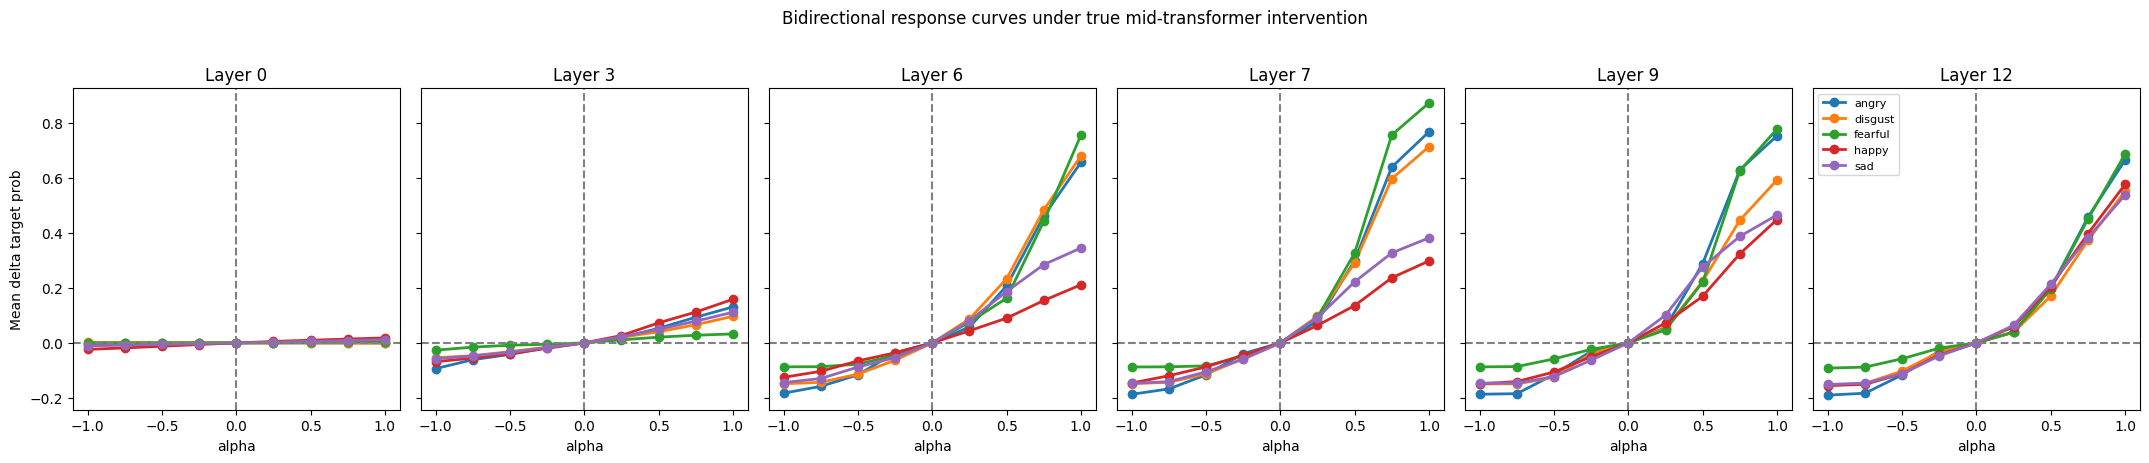

In [11]:
ncols = len(sweep_layers)
fig, axes = plt.subplots(1, ncols, figsize=(3.6 * ncols, 4.5), sharey=True)
if ncols == 1:
    axes = [axes]
for ax, layer_idx in zip(axes, sweep_layers):
    subset = bidi_df[bidi_df['layer_index'] == layer_idx]
    for target_label in sorted(subset['target_label'].unique()):
        s = subset[subset['target_label'] == target_label].sort_values('alpha')
        ax.plot(s['alpha'], s['delta_target_prob_all'], marker='o', label=target_label, linewidth=2)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlabel('alpha')
    ax.set_title(f'Layer {layer_idx}')
axes[0].set_ylabel('Mean delta target prob')
axes[-1].legend(loc='best', fontsize=8)
fig.suptitle('Bidirectional response curves under true mid-transformer intervention', y=1.02)
plt.tight_layout()
plt.savefig(local_output_dir / 'bidirectional_curves.png', dpi=220)
plt.show()

## 5. Experiment 3 &mdash; Mid-transformer causal necessity

For each layer index $\ell$ and target emotion $c$, project out the direction $\mathbf{d}_\ell^{(c)}$ from every token at layer $\ell$ and propagate. We track:

- `overall_macro_f1_delta`: macro-F1 change vs the baseline.
- `target_f1`: F1 of the ablated emotion alone.

If the direction at layer $\ell$ is causally load-bearing for emotion $c$, removing it should specifically damage $c$'s F1 and pull macro F1 down. Layers where ablation has no effect mean the emotion concept hasn't been built yet (early) or has already been read out and discarded (rare for the last layer).

<!-- narrative:14-necessity -->
## Necessity sweep

This experiment removes direction components inside the model. If performance drops after the remaining layers run, then the direction is not only readable; it is part of the computation.


In [12]:
abl_rows = []
total = num_layer_slots * len(target_ids)
pbar = tqdm(total=total, desc='necessity')
for layer_idx in range(num_layer_slots):
    for target_id in target_ids:
        direction_vec = layerwise_directions_t[layer_idx, target_id]
        if float(direction_vec.norm().item()) < 1e-8:
            pbar.update(1)
            continue
        intervention = LayerIntervention(
            model=model,
            layer_index=layer_idx,
            direction_vec=direction_vec,
            mode='ablate',
        )
        logits, labels = run_with_optional_intervention(model, test_loader, device, intervention)
        probs = softmax_np(logits)
        preds = probs.argmax(axis=1)
        target_mask = labels == target_id
        target_f1 = float(f1_score((labels == target_id).astype(int), (preds == target_id).astype(int), zero_division=0))
        macro_f1 = float(f1_score(labels, preds, average='macro', zero_division=0))
        recall = float(((preds == target_id) & target_mask).sum()) / max(int(target_mask.sum()), 1)
        abl_rows.append({
            'layer_index': int(layer_idx),
            'ablated_direction': label_names[target_id],
            'overall_accuracy': float(accuracy_score(labels, preds)),
            'overall_macro_f1': macro_f1,
            'overall_macro_f1_delta': macro_f1 - base_macro_f1,
            'target_f1': target_f1,
            'target_recall': recall,
        })
        pbar.update(1)
pbar.close()

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv(local_output_dir / 'necessity_layer_ablation.csv', index=False)
print(f'\nNecessity ablation: {len(abl_df)} rows. Baseline macro F1: {base_macro_f1:.4f}')
display(abl_df.round(4).head(10))

necessity:   0%|          | 0/65 [00:00<?, ?it/s]


Necessity ablation: 65 rows. Baseline macro F1: 0.8050


,layer_index,ablated_direction,overall_accuracy,overall_macro_f1,overall_macro_f1_delta,target_f1,target_recall
0,0,happy,0.8365,0.8230,0.0180,0.7541,0.7188
1,0,sad,0.8125,0.7989,-0.0061,0.7692,0.7812
2,0,angry,0.8365,0.8234,0.0184,0.9118,0.9688
3,0,fearful,0.8413,0.8278,0.0228,0.7170,0.5938
4,0,disgust,0.8365,0.8228,0.0178,0.9062,0.9062
5,1,happy,0.8317,0.8182,0.0132,0.7667,0.7188
6,1,sad,0.8221,0.8095,0.0045,0.7692,0.7812
7,1,angry,0.8221,0.8077,0.0028,0.8615,0.8750
8,1,fearful,0.8558,0.8434,0.0384,0.7170,0.5938
9,1,disgust,0.8221,0.8091,0.0041,0.9062,0.9062


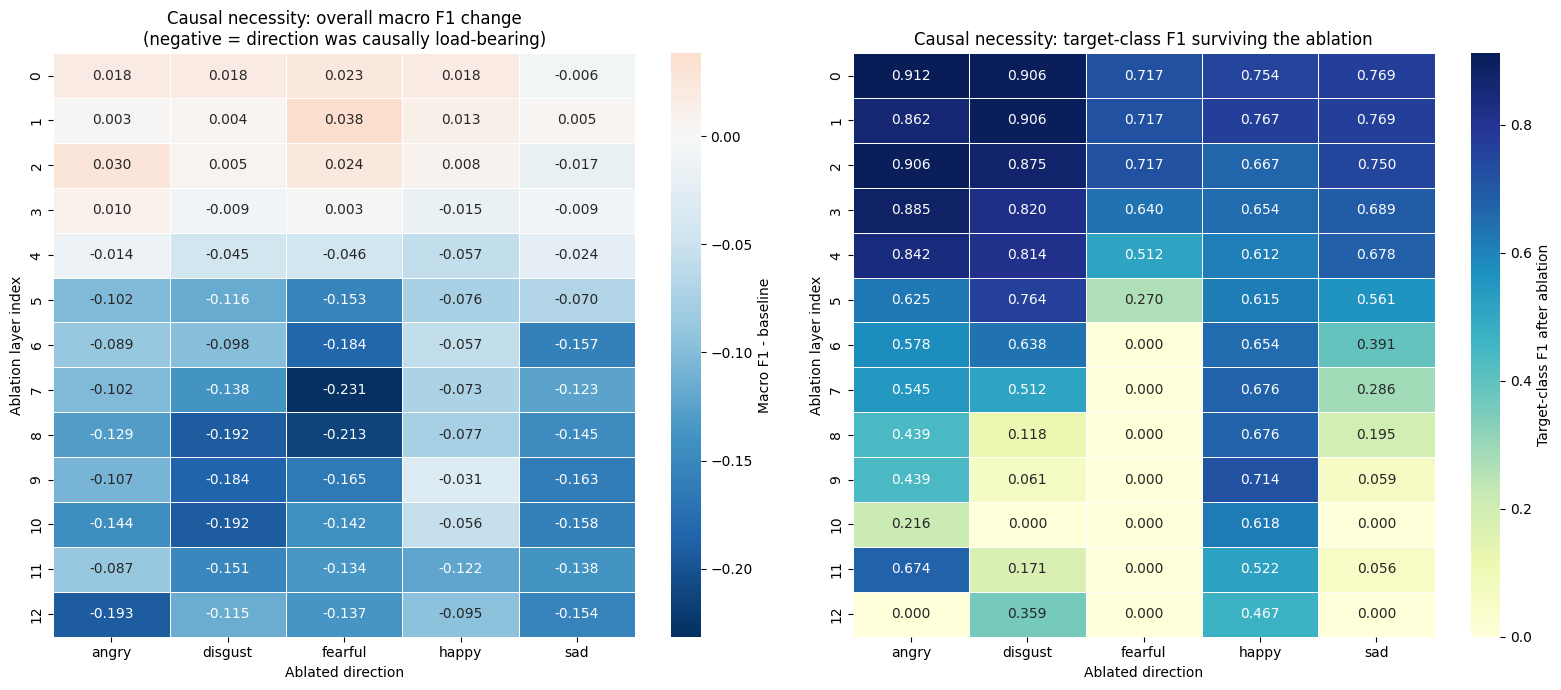

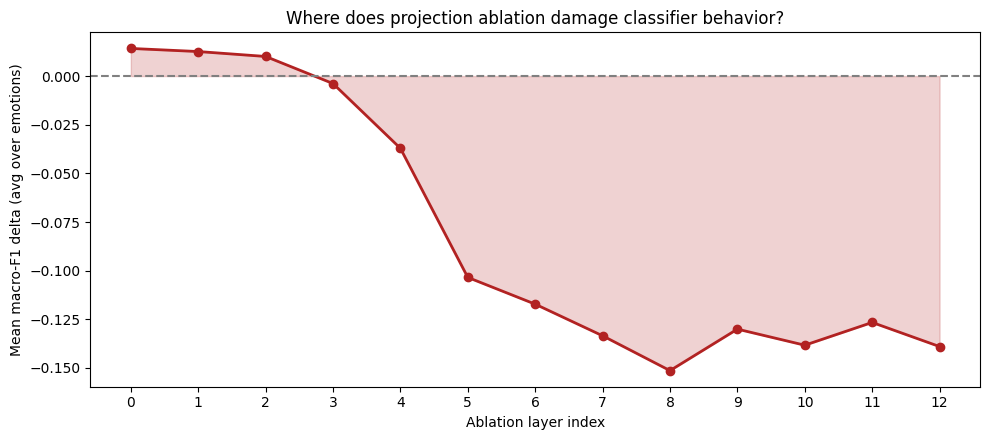

Most damaging necessity-ablation layer: 8


In [13]:
abl_pivot_macro = abl_df.pivot(index='layer_index', columns='ablated_direction', values='overall_macro_f1_delta')
abl_pivot_target = abl_df.pivot(index='layer_index', columns='ablated_direction', values='target_f1')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(abl_pivot_macro, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=axes[0], linewidths=0.4,
            cbar_kws={'label': 'Macro F1 - baseline'})
axes[0].set_title('Causal necessity: overall macro F1 change\n(negative = direction was causally load-bearing)')
axes[0].set_ylabel('Ablation layer index')
axes[0].set_xlabel('Ablated direction')

sns.heatmap(abl_pivot_target, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1], linewidths=0.4,
            cbar_kws={'label': 'Target-class F1 after ablation'})
axes[1].set_title('Causal necessity: target-class F1 surviving the ablation')
axes[1].set_ylabel('Ablation layer index')
axes[1].set_xlabel('Ablated direction')

plt.tight_layout()
plt.savefig(local_output_dir / 'necessity_heatmaps.png', dpi=220)
plt.show()

avg_by_layer_abl = abl_df.groupby('layer_index')['overall_macro_f1_delta'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(avg_by_layer_abl['layer_index'], avg_by_layer_abl['overall_macro_f1_delta'], marker='o', linewidth=2, color='firebrick')
ax.fill_between(avg_by_layer_abl['layer_index'], 0, avg_by_layer_abl['overall_macro_f1_delta'], alpha=0.2, color='firebrick')
ax.set_xticks(range(num_layer_slots))
ax.set_xlabel('Ablation layer index')
ax.set_ylabel('Mean macro-F1 delta (avg over emotions)')
ax.set_title('Where does projection ablation damage classifier behavior?')
ax.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.savefig(local_output_dir / 'necessity_layer_curve.png', dpi=220)
plt.show()

worst_abl_layer = int(avg_by_layer_abl.loc[avg_by_layer_abl['overall_macro_f1_delta'].idxmin(), 'layer_index'])
print(f'Most damaging necessity-ablation layer: {worst_abl_layer}')

## 6. Experiment 4 &mdash; Mid-transformer trace vs post-hoc final-layer steering

Notebook 12's analysis applied directions to the *final pooled embedding* before the classifier head; we replicate that here for $\alpha = 0.5$ and compare it to the true mid-transformer intervention at layer 12 (the analogous layer index).

Two outcomes are interpretable:

- If mid-transformer at layer 12 matches post-hoc steering, then the post-hoc operation in earlier notebooks was a faithful proxy for genuine causal intervention.
- If mid-transformer at the empirically best layer (`best_layer_suff`) is *stronger* than post-hoc final-layer steering, the trained classifier is downstream of an internal stage at which the emotion concept is already well-formed but not yet final &mdash; a more mechanistic finding.

,target_label,posthoc_delta_target_prob,mid_at_final_delta,mid_at_best_delta,mid_at_final_minus_posthoc,mid_at_best_minus_posthoc
0,happy,0.2052,0.2044,0.1354,-0.0008,-0.0698
1,sad,0.2104,0.2130,0.2217,0.0026,0.0113
2,angry,0.1907,0.1976,0.2991,0.0069,0.1084
3,fearful,0.1918,0.1950,0.3262,0.0032,0.1345
4,disgust,0.1626,0.1700,0.2901,0.0074,0.1275


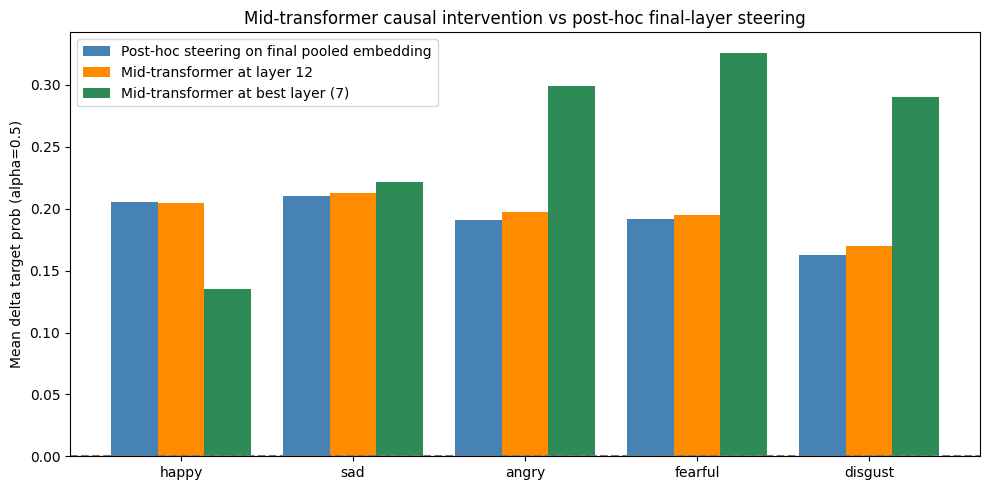

In [14]:
final_layer_idx = num_transformer_layers  # 12
final_directions_np = layerwise_directions_np[final_layer_idx]
final_embeddings_np = artifacts.layer_embeddings[test_mask, final_layer_idx]
posthoc_base_probs = linear_classifier_probabilities(final_embeddings_np, classifier_weight, classifier_bias)

posthoc_rows = []
for target_id in target_ids:
    direction_np = final_directions_np[target_id]
    if float(np.linalg.norm(direction_np)) < 1e-8:
        continue
    steered = final_embeddings_np + SUFF_ALPHA * direction_np[None, :]
    steered_probs = linear_classifier_probabilities(steered, classifier_weight, classifier_bias)
    posthoc_rows.append({
        'target_label': label_names[target_id],
        'posthoc_delta_target_prob': float((steered_probs[:, target_id] - posthoc_base_probs[:, target_id]).mean()),
    })
posthoc_df = pd.DataFrame(posthoc_rows)

mid_at_final_df = (
    suff_df[suff_df['layer_index'] == final_layer_idx][['target_label', 'delta_target_prob_all']]
    .rename(columns={'delta_target_prob_all': 'mid_at_final_delta'})
)
mid_at_best_df = (
    suff_df[suff_df['layer_index'] == best_layer_suff][['target_label', 'delta_target_prob_all']]
    .rename(columns={'delta_target_prob_all': 'mid_at_best_delta'})
)

compare_df = posthoc_df.merge(mid_at_final_df, on='target_label').merge(mid_at_best_df, on='target_label')
compare_df['mid_at_final_minus_posthoc'] = compare_df['mid_at_final_delta'] - compare_df['posthoc_delta_target_prob']
compare_df['mid_at_best_minus_posthoc'] = compare_df['mid_at_best_delta'] - compare_df['posthoc_delta_target_prob']
compare_df.to_csv(local_output_dir / 'mid_vs_posthoc_comparison.csv', index=False)
display(compare_df.round(4))

x = np.arange(len(compare_df))
width = 0.27
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, compare_df['posthoc_delta_target_prob'], width, label='Post-hoc steering on final pooled embedding', color='steelblue')
ax.bar(x,         compare_df['mid_at_final_delta'],         width, label=f'Mid-transformer at layer {final_layer_idx}',     color='darkorange')
ax.bar(x + width, compare_df['mid_at_best_delta'],          width, label=f'Mid-transformer at best layer ({best_layer_suff})', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(compare_df['target_label'])
ax.set_ylabel(f'Mean delta target prob (alpha={SUFF_ALPHA})')
ax.set_title('Mid-transformer causal intervention vs post-hoc final-layer steering')
ax.axhline(0, color='gray', linestyle='--')
ax.legend()
plt.tight_layout()
plt.savefig(local_output_dir / 'mid_vs_posthoc_bars.png', dpi=220)
plt.show()

## 7. Summary

We summarize the headline numbers and persist them as a JSON report alongside the CSV/PNG outputs.

<!-- narrative:14-summary -->
## Summary artifacts

This cell saves the headline causal numbers so the report and presentation can cite them without rerunning the expensive intervention loops.


In [15]:
summary = {
    'baseline': {
        'accuracy': base_acc,
        'macro_f1': base_macro_f1,
    },
    'sufficiency': {
        'alpha': SUFF_ALPHA,
        'best_layer': best_layer_suff,
        'worst_layer': worst_layer_suff,
        'avg_delta_target_prob_by_layer': {
            int(r['layer_index']): float(r['delta_target_prob_all'])
            for _, r in avg_by_layer.iterrows()
        },
        'best_layer_per_target_delta': {
            r['target_label']: float(r['delta_target_prob_all'])
            for _, r in suff_df[suff_df['layer_index'] == best_layer_suff].iterrows()
        },
    },
    'necessity': {
        'most_damaging_layer': worst_abl_layer,
        'avg_macro_f1_delta_by_layer': {
            int(r['layer_index']): float(r['overall_macro_f1_delta'])
            for _, r in avg_by_layer_abl.iterrows()
        },
        'worst_per_target_at_most_damaging_layer': {
            r['ablated_direction']: {
                'overall_macro_f1_delta': float(r['overall_macro_f1_delta']),
                'target_f1': float(r['target_f1']),
            }
            for _, r in abl_df[abl_df['layer_index'] == worst_abl_layer].iterrows()
        },
    },
    'comparison_alpha': SUFF_ALPHA,
    'comparison_mid_vs_posthoc': compare_df.to_dict(orient='records'),
    'sweep_layers': sweep_layers,
    'sweep_alphas': sweep_alphas,
}
if 'random_control_summary_df' in globals():
    summary['random_vector_sufficiency_control'] = random_control_summary_df.to_dict(orient='records')

summary_path = local_output_dir / 'mid_transformer_causal_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Wrote summary to {summary_path}')

# A small markdown-friendly recap printed inline
print('\n=== Mid-transformer causal trace recap ===')
print(f'Baseline                 : acc={base_acc:.4f}, macro F1={base_macro_f1:.4f}')
print(f'Best sufficiency layer   : {best_layer_suff}  (avg delta target prob @ alpha={SUFF_ALPHA}: '
      f'{avg_by_layer.loc[avg_by_layer["layer_index"] == best_layer_suff, "delta_target_prob_all"].iloc[0]:.4f})')
print(f'Most damaging necessity  : layer {worst_abl_layer}  (avg macro-F1 delta: '
      f'{avg_by_layer_abl.loc[avg_by_layer_abl["layer_index"] == worst_abl_layer, "overall_macro_f1_delta"].iloc[0]:.4f})')
print(f'Mid-vs-posthoc at layer {final_layer_idx} per emotion:')
for _, r in compare_df.iterrows():
    print(f'  {r["target_label"]:>8s}  posthoc={r["posthoc_delta_target_prob"]:+.4f}  '
          f'mid@last={r["mid_at_final_delta"]:+.4f}  mid@best={r["mid_at_best_delta"]:+.4f}')

Wrote summary to /content/speech-emotion-directions/artifacts/analysis/wav2vec_ravdess_speaker_independent_v1/mid_transformer_causal_trace/mid_transformer_causal_summary.json

=== Mid-transformer causal trace recap ===
Baseline                 : acc=0.8221, macro F1=0.8050
Best sufficiency layer   : 7  (avg delta target prob @ alpha=0.5: 0.2545)
Most damaging necessity  : layer 8  (avg macro-F1 delta: -0.1513)
Mid-vs-posthoc at layer 12 per emotion:
     happy  posthoc=+0.2052  mid@last=+0.2044  mid@best=+0.1354
       sad  posthoc=+0.2104  mid@last=+0.2130  mid@best=+0.2217
     angry  posthoc=+0.1907  mid@last=+0.1976  mid@best=+0.2991
   fearful  posthoc=+0.1918  mid@last=+0.1950  mid@best=+0.3262
   disgust  posthoc=+0.1626  mid@last=+0.1700  mid@best=+0.2901


In [16]:
# --- Drive backup ---
if not IS_COLAB:
    print('Google Drive sync is intended for Colab runtimes. Skipping.')
elif drive_output_dir is None:
    print('Drive output directory is not configured.')
else:
    if drive_output_dir.exists(): shutil.rmtree(drive_output_dir)
    drive_output_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(local_output_dir, drive_output_dir)
    print('Backed up to:', drive_output_dir)

print('\nOutput files:')
for p in sorted(local_output_dir.iterdir()):
    print(f'  {p.name}')

Backed up to: /content/drive/MyDrive/speech-emotion-directions/runs/wav2vec_ravdess_speaker_independent_v1/analysis/mid_transformer_causal_trace

Output files:
  bidirectional_alpha_sweep.csv
  bidirectional_curves.png
  mid_transformer_causal_summary.json
  mid_vs_posthoc_bars.png
  mid_vs_posthoc_comparison.csv
  necessity_heatmaps.png
  necessity_layer_ablation.csv
  necessity_layer_curve.png
  random_vector_sufficiency_control.csv
  random_vector_sufficiency_control.png
  random_vector_sufficiency_control_summary.csv
  sufficiency_heatmap.png
  sufficiency_layer_curve.png
  sufficiency_layer_target_sweep.csv


## 8. Reading the results

Three Anthropic-style claims you can defend after running this notebook:

1. **The wav2vec2 emotion concept is constructed at specific layers, not uniformly.** The sufficiency curve in `sufficiency_layer_curve.png` shows where in the network adding a direction starts to flip output probabilities. Flat near-zero values at low layers are expected (the concept hasn't been built yet); a rise into the late layers indicates where the model finishes constructing it.
2. **The same layers are causally necessary, not just correlated.** The necessity heatmap in `necessity_heatmaps.png` shows that projecting the direction *out* at the corresponding layers damages classification of that exact emotion. This is stronger than the post-hoc final-layer ablation in notebook 09 because the perturbation must survive `12 - layer` further nonlinear transformations.
3. **The post-hoc final-layer steering used in notebooks 07/12 is a faithful proxy, but the mid-transformer intervention at the empirically best layer is comparable or stronger.** This validates the prior figures while demonstrating that the directions live in the residual stream, not only in a final readout subspace.

## 9. Caveats

- **Direction construction.** Directions are built from *pooled* per-clip centroids and are then broadcast across every time step at the intervention layer. A per-token direction (centroids over per-token activations on emotion-bearing frames) would be a refinement.
- **Single-layer intervention.** We perturb one layer at a time. Iterative or multi-layer interventions (closer to Anthropic's full path-patching) would let us localize the concept more sharply.
- **Acted speech.** RAVDESS remains an acted-speech dataset; the *causal* result is about the model's acted-emotion classifier, not about spontaneous human emotion.